# Representing geographic data as networks

As we briefly introduced in Chapter 5.2, networks are data structures that consists of nodes that are connected to other nodes via edges which ultimately construct a network topology (or a graph as it is referred in graph theory). In this section, we will show how you can construct spatial networks using Python based on geographic data. We will show how you can create a simple graph from scratch, as well as how to create a network from a given dataset with `LineString` objects or from OpenStreetMap data that makes it possible to create networks from all over the world that can be used for various network analysis purposes.

Contents:

- Basic concepts: nodes, edges, node/edge attributes, topology, connectivity, directionality, what Python tools are out there that can be used?
- How to create a simple graph from scratch
- How to create a graph from a file representing streets
- How to create a routable graph from OpenStreetMap
- Other uses of graphs - morphology, spatial weights, etc.
- Saving graphs to disk

## Basic concepts

As networks are widely used in various domains, the terminology related to networks can at times be a bit confusing. To clarify some of the ambiguity related to the terminology, we will start by going through some common network-related terms to make it clear how we refer to these terms in this book emphasizing the linkage to GIS.

`Node` is a point that together with `edges` construct a `graph` (Figure 8.1). In GIS, `node` typically refers to a specific point location, such as intersection in the street network, but in other contexts, it can represent various other things, such as persons or computers (a node can represent about anything really). In graph theory, `node` is typically called as `vertex`. However, in GIS, there is a distiction between the two: `node` is specific to a point at which a line ends or connects to another line, whereas `vertices` can be in between the `nodes` as intermediate points constructing the shape of a given line geometry (e.g. a curved road). Thus, every `node` of a `graph` can be considered as a `vertex` but not all `vertices` are `nodes`. 

`Edge` is a connection between two `nodes`. Sometimes `edge` is also called as `line` or `link`, and a `directed edge` can be called as an `arc` (in graph theory). Edges can have attributes associated with them (e.g. distance, volume, capacity) which make them very useful data structure for various analytical purposes, such as conducting way-finding where the target is to find an optimal path between two locations on a network. When working with real-world networks (e.g. street networks), it is typical that the actual geometry of the street segment is simplified when constructing the graph and only the nodes are kept (i.e. the first and last point of a `LineString`). 

`Graph` is a collection of `nodes` and `edges` that constitutes a graph structure (term used in graph theory). `Graph` is an abstract concept commonly used e.g. in mathematics and computer science which emphasizes the connections and relationships between entities (nodes) rather than exact geographic positions or distances. `Network topology` is a commonly used term in GIS, which is ultimately a same thing as a `graph`.

`Spatial network` or `geometric network` is a **graph with attributes** that is used to represent real-world systems on a geographic space. For example, street network is typically not only represented as a collection of `nodes` (intersections) and `edges` (streets) but there are various additional attributes associated with the network, such as speed limit, number of lanes, the location of crossroads etc. In practice, the terms `graph`, `network` and `spatial network` are often used in synonymous manner, although there are subtle differences in terms of their definitions. In this book, we use the term and variable `network` (or `net` in short) when we talk about a real-world spatial networks with various attributes and a `graph` (variable `G`) if we talk about a graph structure without linkage to geographical space.

Graphs and networks can be `directed` or `undirected` (Figure 8.1), which determines the `directionality`, i.e. in which direction the nodes are connected to each other. In broad terms, this directionality determines how the interaction happens (or is allowed to happen) between the nodes. For example in terms of street networks, the roads can be travelled to any direction on an undirected network but with the directed network the travel direction is restricted to a certain direction (e.g. due to one-way-streets). Undirected graphs are commonly used e.g. with  walking and cycling related network analysis, as with those travel modes it is typically possible to travel the same street in any direction you like. Directed graphs are commonly used when considering driving, as there are stricter rules in terms of how the roads of the city can be traversed by cars.

`Connectivity` refers to the ability of a given network to maintain a connection between cope with failure

![_**Figure 8.1.** A directed graph._](../img/directed_graph.png)

_**Figure 8.1.** A directed graph._



: _**Table 5.1.** Edges for each direction._

| edge_id | from_node | to_node| description |
|---------|-----------|--------|-------------|
|1| A| C |  *edge for direction 1* |
|2| C| A |  *edge for direction 2* |

In the following, we will dive deeper to all of these aspects and construct various types of networks which aim to make it easier to understand how all of this works using Python.

## Creating a simple network from scratch

### Undirected graph

In this first example, we will construct a simple graph using the `networkx` library and its `nx.Graph()` construct that allows you to create an undirected graph with nodes and edges. 

In [25]:
import networkx as nx
import matplotlib.pyplot as plt
from shapely import Point

G = nx.Graph()
G

In [26]:
# Add nodes
G.add_node("a")
G.add_node("b")
G.add_node("c")
G.add_node("d")
G.add_node("e")

# Add edges            
G.add_edge("a", "b")
G.add_edge("a", "c")
G.add_edge("b", "d")
G.add_edge("c", "d")
G.add_edge("d", "e")

In [29]:
G.nodes

NodeView(('a', 'b', 'c', 'd', 'e'))

In [30]:
G.edges

EdgeView([('a', 'b'), ('a', 'c'), ('b', 'd'), ('c', 'd'), ('d', 'e')])

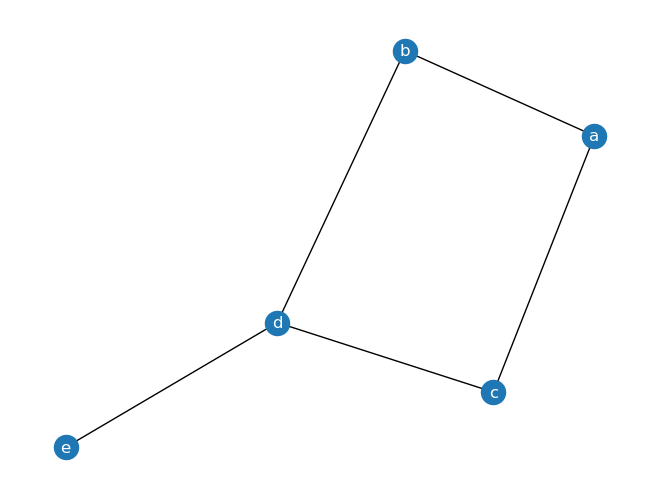

In [28]:
nx.draw(G, with_labels=True, font_color="white")

In [38]:
net = nx.Graph()

node_collection = [("a", {"coords": (0,5)}),
                   ("b", {"coords": (5,5)}),
                   ("c", {"coords": (0,0)}),
                   ("d", {"coords": (5,0)}),
                   ("e", {"coords": (10,0)}),
                  ]

edge_collection = [("a", "b", {"weight": 1}),
                   ("a", "c", {"weight": 2}),
                   ("b", "d", {"weight": 1}),
                   ("c", "d", {"weight": 1}),
                   ("d", "e", {"weight": 3}),
                  
                  ]

# Add nodes and edges from the collections
net.add_nodes_from(node_collection)
net.add_edges_from(edge_collection)

In [39]:
net.nodes.data()

NodeDataView({'a': {'coords': (0, 5)}, 'b': {'coords': (5, 5)}, 'c': {'coords': (0, 0)}, 'd': {'coords': (5, 0)}, 'e': {'coords': (10, 0)}})

In [40]:
net.edges.data()

EdgeDataView([('a', 'b', {'weight': 1}), ('a', 'c', {'weight': 2}), ('b', 'd', {'weight': 1}), ('c', 'd', {'weight': 1}), ('d', 'e', {'weight': 3})])

In [41]:
# Extract node locations
positions = {node: attrs["coords"] for node, attrs in net.nodes.data()}
positions

{'a': (0, 5), 'b': (5, 5), 'c': (0, 0), 'd': (5, 0), 'e': (10, 0)}

In [42]:
# Parse edge labels
edge_labels = {(u, v): attrs["weight"] for u, v, attrs in net.edges.data()}
edge_labels

{('a', 'b'): 1, ('a', 'c'): 2, ('b', 'd'): 1, ('c', 'd'): 1, ('d', 'e'): 3}

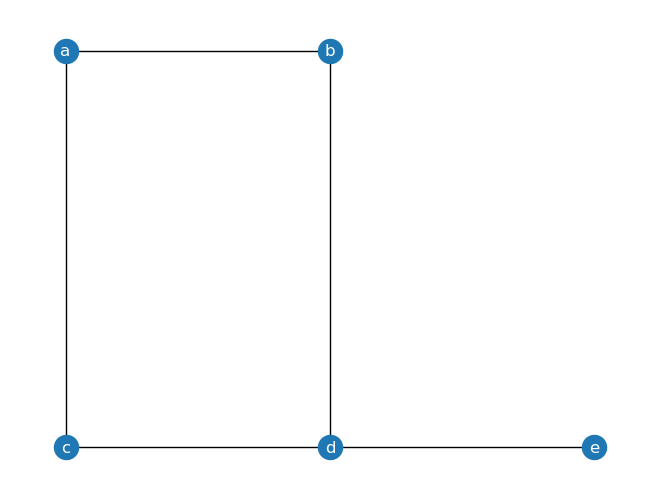

In [43]:
nx.draw(net, with_labels=True, pos=positions, font_color="white")

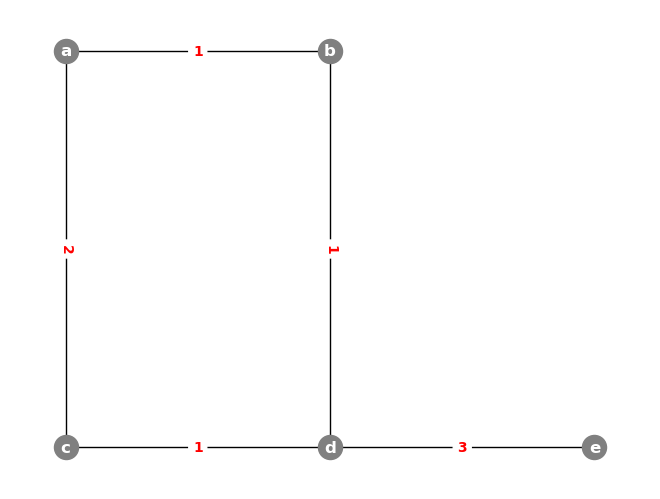

In [44]:
# Draw the graph
nx.draw(net, 
        pos=positions, 
        with_labels=True, 
        font_weight="bold", 
        font_color="white", 
        node_color="grey"
)

# Add edge labels
nx.draw_networkx_edge_labels(
    net, 
    positions,
    edge_labels=edge_labels,
    font_color='red', 
    font_weight="bold",
);

_**Figure 8.X.** A simple undirected spatial network consisting of five nodes and edges._

Although, you can easily add nodes and edges one at a time as shown previously, it is not typically very efficient way of construcing a graph. Luckily, `networkx` also allows you to pass the information for the graphs from a collection of items. Thus, we can create an identical graph as shown previously by passing a collection of nodes and edges to the graph as follows:

In [206]:
G2 = nx.Graph()

node_collection = [("a", {"coords": (0,5)}),
                   ("b", {"coords": (5,5)}),
                   ("c", {"coords": (0,0)}),
                   ("d", {"coords": (5,0)}),
                   ("e", {"coords": (10,0)}),
                  ]

edge_collection = [("a", "b", {"weight": 1}),
                   ("a", "c", {"weight": 2}),
                   ("b", "d", {"weight": 1}),
                   ("c", "d", {"weight": 1}),
                   ("d", "e", {"weight": 3}),
                  
                  ]

# Add nodes and edges from the collections
G2.add_nodes_from(node_collection)
G2.add_edges_from(edge_collection)

# Extract exact node locations
positions = {node: attrs["coords"] for node, attrs in G2.nodes.data()}

# Parse edge labels
edge_labels = {(u, v): attrs["weight"] for u, v, attrs in G2.edges.data()}

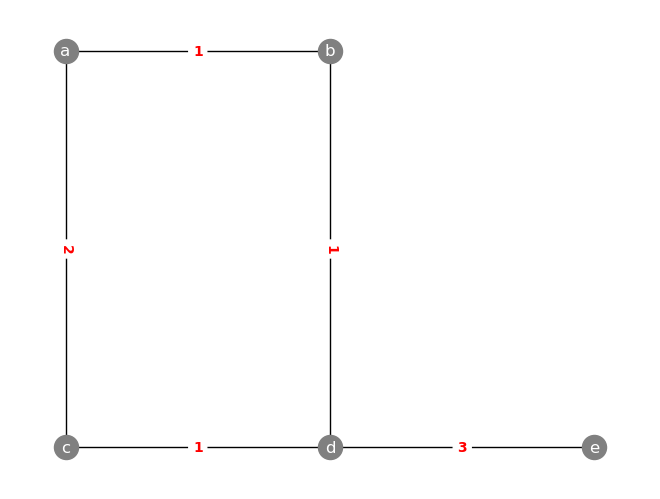

In [207]:
nx.draw(G2, 
        with_labels=True, 
        pos=positions, 
        font_color="white", 
        node_color="grey")

nx.draw_networkx_edge_labels(
    G2, 
    positions,
    edge_labels=edge_labels,
    font_color='red', 
    font_weight="bold",
);

In [208]:
distance, path = nx.single_source_dijkstra(G=G2, 
                                          source="a",
                                          target="e", 
                                          weight="weight", 
                                          )

In [209]:
print("Distance:", distance)
print("Path / visited nodes:", path)

Distance: 5
Path / visited nodes: ['a', 'b', 'd', 'e']


In [210]:
distance, path = nx.single_source_dijkstra(G=G2, 
                                          source="e",
                                          target="a", 
                                          weight="weight", 
                                          )

In [211]:
print("Distance:", distance)
print("Path / visited nodes:", path)

Distance: 5
Path / visited nodes: ['e', 'd', 'b', 'a']


In [212]:
path_edges = list(zip(path,path[1:]))
path_edges

[('e', 'd'), ('d', 'b'), ('b', 'a')]

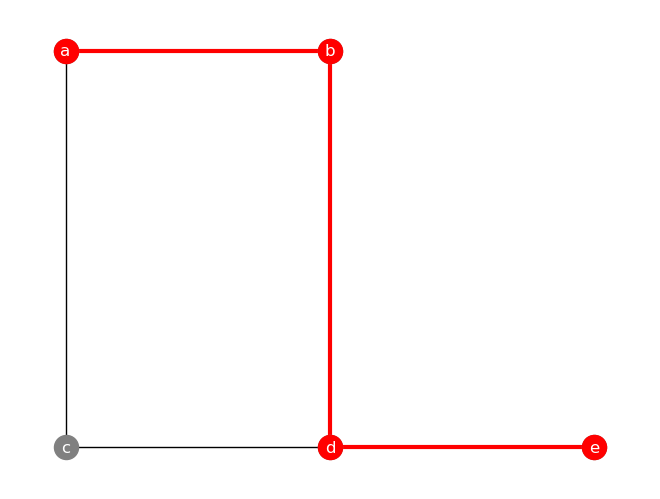

In [216]:
nx.draw(G2, 
        with_labels=True, 
        pos=positions, 
        font_color="white", 
        node_color="grey")

nx.draw_networkx_nodes(G2, positions, nodelist=path, node_color='r')
nx.draw_networkx_edges(G2, positions, edgelist=path_edges, edge_color='r', width=3);

### Directed graph

In [173]:
G_directed = nx.MultiDiGraph()

In [174]:
node_collection = [("a", {"coords": (0,5)}),
                   ("b", {"coords": (5,5)}),
                   ("c", {"coords": (0,0)}),
                   ("d", {"coords": (5,0)}),
                   ("e", {"coords": (10,0)}),
                  ]

In [176]:
edge_collection = [("a", "b", {"weight": 1, "color": "red"}),
                   # bidirectional a<->c
                   ("a", "c", {"weight": 2, "color": "green"}),
                   ("c", "a", {"weight": 2, "color": "green"}),
                   # bidirectional b<->d
                   ("b", "d", {"weight": 1, "color": "green"}),
                   ("d", "b", {"weight": 1, "color": "green"}),
                   
                   ("c", "d", {"weight": 1, "color": "red"}),
                   ("d", "e", {"weight": 3, "color": "red"}),
                  ]

In [181]:
# Add nodes and edges from the collections
G_directed.add_nodes_from(node_collection)
G_directed.add_edges_from(edge_collection)

# Extract exact node locations
positions = {node: attrs["coords"] for node, attrs in G_directed.nodes.data()}

# Parse edge labels
edge_labels = {(u, v): attrs["weight"] for u, v, attrs in G_directed.edges.data()}

# Parse edge colors
edge_colors = [attrs["color"] for u, v, attrs in G_directed.edges.data()]

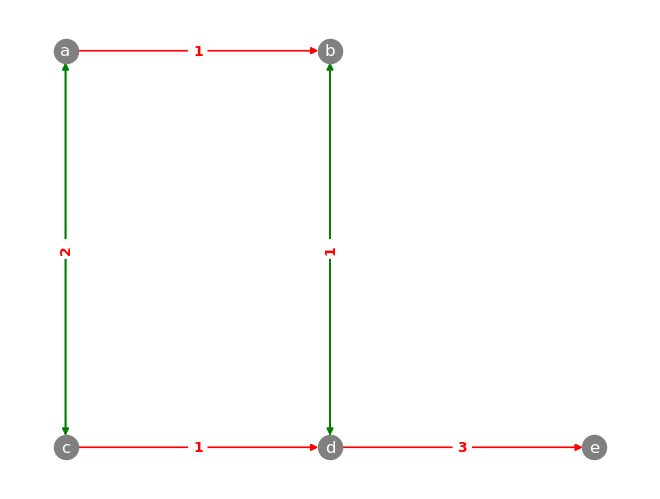

In [182]:
nx.draw(G_directed, 
        with_labels=True, 
        pos=positions, 
        font_color="white", 
        node_color="grey",
        edge_color=edge_colors
       )

nx.draw_networkx_edge_labels(
    G_directed, 
    positions,
    edge_labels=edge_labels,
    font_color='red', 
    font_weight="bold",
);

In [218]:
distance, path = nx.single_source_dijkstra(G=G_directed, 
                                          source="a",
                                          target="e", 
                                          weight="weight", 
                                          )

In [219]:
path_edges = list(zip(path,path[1:]))
path_edges

[('a', 'b'), ('b', 'd'), ('d', 'e')]

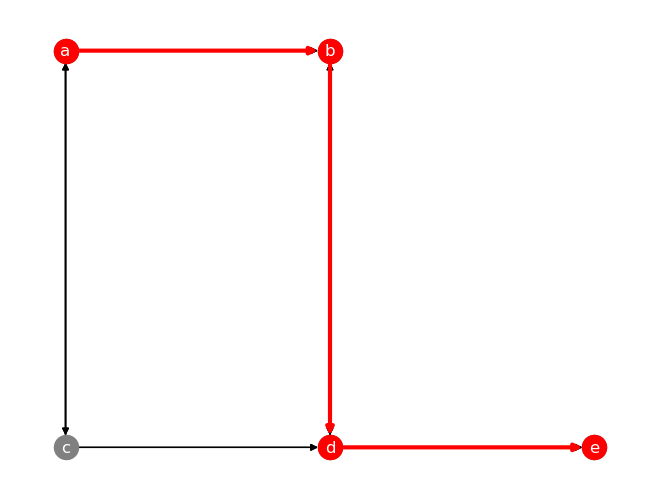

In [220]:
nx.draw(G_directed, 
        with_labels=True, 
        pos=positions, 
        font_color="white", 
        node_color="grey")

nx.draw_networkx_nodes(G_directed, positions, nodelist=path, node_color='r')
nx.draw_networkx_edges(G_directed, positions, edgelist=path_edges, edge_color='r', width=3);

#### Question 8.1

What is the path length and route from `e` to `a` using the directed graph? 

In [ ]:
# You can use this cell to enter your solution.

In [223]:
# Solution

# This is a trick question: Because our graph is directed
# and there is no way out from node 'e', there is no path nor length
# from e to a

# When searching for such a path, networkx raises an error

# Uncomment to test yourself
# distance, path = nx.single_source_dijkstra(G=G_directed, source="e", target="a", weight="weight")

## Creating a graph from geometries

### Undirected graph using a GeoDataFrame

Data was obtained from Digiroad

In [515]:
import geopandas as gpd

fp = "data/digiroad_helsinki.gpkg"
streets = gpd.read_file(fp)
streets.head()

,id,direction,maxspeed,road_class,name,geometry
0,0,4,30,4,Uudenmaankatu,"LINESTRING Z (385359.222 6671266.76 8.729, 385..."
1,1,3,40,4,Pitkäsilta,"LINESTRING Z (386282.417 6672754.728 4.562, 38..."
2,2,3,30,5,Kruunuvuorenkatu,"LINESTRING Z (387294.871 6671561.901 2.24, 387..."
3,3,2,30,5,Kristianinkatu,"LINESTRING Z (386646.115 6672721.35 16.528, 38..."
4,4,2,30,5,Fabianinkatu,"LINESTRING Z (386225.349 6671530.049 8.246, 38..."


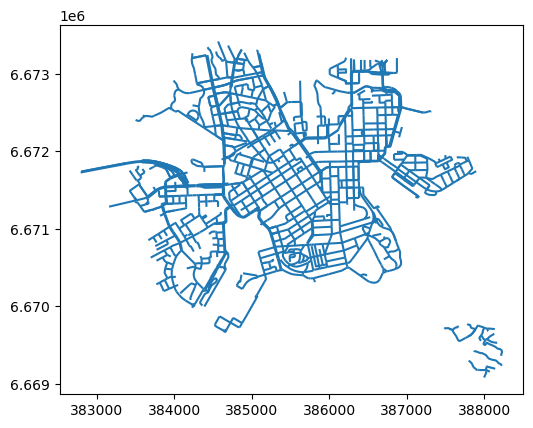

In [516]:
streets.plot();

In [517]:
def gdf_to_graph(gdf):
    """Creates a NetworkX Graph from GeoDataFrame consisting of LineString objects.

    Parameters
    ----------

    gdf : GeoDataFrame
        GeoDataFrame containing the LineString data.

    """

    # Create the NetworkX graph
    graph = nx.Graph()
        
    # Generate edge dictionary
    for edge in gdf.itertuples():
        coords = edge.geometry.coords

        # Get first and last node of the edge (excluding vertices)
        first, last = coords[0], coords[-1]

        # Edge attributes
        edge_attr = edge._asdict()

        graph.add_edge(first, last, **edge_attr)

    # Generate node attributes
    node_attrs = {node: {"coords": node, "x": node[0], "y": node[1]} for node in graph.nodes}
    nx.set_node_attributes(graph, node_attrs)  
    
    # Relabel the indices
    graph = nx.convert_node_labels_to_integers(graph)

    # Add some useful attributes    
    graph.graph['crs'] = gdf.crs

    return graph

Next we will break it down few steps at a time to understand what happens here. Let's start by investigating what happens inside the loop:

In [518]:
graph = nx.Graph()

for edge in streets.itertuples():
    # Get the coordinates
    coords = edge.geometry.coords

    # Get first and last node of the edge (excluding vertices)
    first, last = coords[0], coords[-1]

    # Get the edge attributes
    edge_attributes = edge._asdict()

    # Add to the graph
    graph.add_edge(first, last, **edge_attributes)
    break

Now we iterated over one edge in our street network and stopped the loop to be able to investigate what our variables contain. The `coords` variable contain the coordinates of all the vertices in the first edge of our street network:

In [519]:
list(coords)

[(385359.22199999995, 6671266.759999999, 8.729),
 (385388.0329999999, 6671288.834, 8.987),
 (385429.82200000004, 6671317.645999999, 8.732)]

As we can see, there are 3 vertices in this `LineString` object representing a given street. When constructing the graph topology, we only care about the `nodes` of the street segment geometry (i.e. the first and last coordinates of the geometry). This means that in case there are vertices between the nodes, those will not be taken into consideration in the topology of the graph (unless specifically needed for some special use case). Thus, the network topology itself does not need to have the full geometry of the street segments for it to work. 

<Axes: >

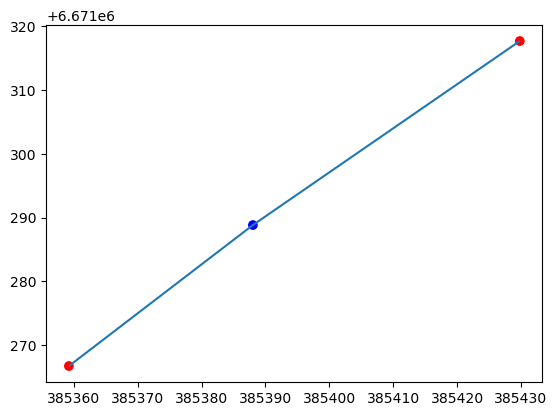

In [520]:
# Create a GeoDataFrame out of the vertices
vertices = gpd.GeoDataFrame(geometry=[Point(coordpair) for coordpair in coords])

fig, ax = plt.subplots()
streets.iloc[0:1].plot(ax=ax)
vertices.plot(ax=ax, color=["r", "b", "r"])

_**Figure 8.X.** Only the nodes (in red) will be used to construct the edge for a given network topology._

Considering only the nodes and ignoring the vertices has also benefits as doing this reduces the size of the graph and makes it faster to run any analyses on it. Thus, we only take the first and last coordinate-pair of the edge geometry which we will use as nodes:

In [521]:
print("First node:", first)
print("Last node:", last)

First node: (385359.22199999995, 6671266.759999999, 8.729)
Last node: (385429.82200000004, 6671317.645999999, 8.732)


Although the network topology only considers the nodes, this does not mean that you would loose the actual geometries of the street network, as we can still store the full geometry as an edge attribute of our graph. The `edge_attributes` variable contains all the associated information from the given row in our `GeoDataFrame` as a dictionary:

In [522]:
edge_attributes

{'Index': 0,
 'id': 0,
 'direction': 4,
 'maxspeed': 30,
 'road_class': 4,
 'name': 'Uudenmaankatu',
 'geometry': <LINESTRING Z (385359.222 6671266.76 8.729, 385388.033 6671288.834 8.987, 38...>}

When we call the `graph.add_edge(first, last, **edge_attributes)`, we add this edge to the given `graph` in which the `**edge_attributes` command unpacks the values of the dictionary and inserts them as attributes for the given edge. Thus, when we investigate the contents of the edges at this point in time, we will see that the actual `geometry` is also stored for the edge:

In [523]:
graph.edges.data()

EdgeDataView([((385359.22199999995, 6671266.759999999, 8.729), (385429.82200000004, 6671317.645999999, 8.732), {'Index': 0, 'id': 0, 'direction': 4, 'maxspeed': 30, 'road_class': 4, 'name': 'Uudenmaankatu', 'geometry': <LINESTRING Z (385359.222 6671266.76 8.729, 385388.033 6671288.834 8.987, 38...>})])

At this point, you might wonder what happened with the `nodes` as we did not specifically add them to the graph in a similar manner as in our earlier examples? We can investigate how the `nodes` look like at this stage:

In [524]:
graph.nodes.data()

NodeDataView({(385359.22199999995, 6671266.759999999, 8.729): {}, (385429.82200000004, 6671317.645999999, 8.732): {}})

As we can see, `networkx` actually adds the nodes automatically to the graph when we call the `.add_edge()` method based on the nodes provided to construct a given edge. However, as we can see from the nodes' data above, these nodes do not contain any information about the nodes in the nodes attributes as it is only an empty dictionary at this stage. This is something that we can handle afterwards as it is possible to set the node attributes also after the topology has been constructed based on the edges alone. To do this, we can e.g. parse the coordinates of the nodes and store that information as node attributes using the `nx.set_node_attributes()` as follows:

In [525]:
# Create a dictionary that contain the node attributes
node_attrs = {node: {"coords": node, "x": node[0], "y": node[1]} for node in graph.nodes}
nx.set_node_attributes(graph, node_attrs)  

In [526]:
graph.nodes.data()

NodeDataView({(385359.22199999995, 6671266.759999999, 8.729): {'coords': (385359.22199999995, 6671266.759999999, 8.729), 'x': 385359.22199999995, 'y': 6671266.759999999}, (385429.82200000004, 6671317.645999999, 8.732): {'coords': (385429.82200000004, 6671317.645999999, 8.732), 'x': 385429.82200000004, 'y': 6671317.645999999}})

As we can see, now the `nodes` of our graph includes three attributes that provide information about the location of the nodes: `coords`, `x` and `y`. 

Finally, you might have noticed that the `ids` for the nodes in our graph are quite cumbersome as they basically represent the exact coordinates of the nodes. Luckily, it is easy to relabel the node ids into a format that is easier to use and understand, using simple integer values as the ids. We can do this by using the `nx.convert_node_labels_to_integers()` function as follows:

In [527]:
graph = nx.convert_node_labels_to_integers(graph)

In [528]:
graph.edges.data()

EdgeDataView([(0, 1, {'Index': 0, 'id': 0, 'direction': 4, 'maxspeed': 30, 'road_class': 4, 'name': 'Uudenmaankatu', 'geometry': <LINESTRING Z (385359.222 6671266.76 8.729, 385388.033 6671288.834 8.987, 38...>})])

In [529]:
graph.nodes.data()

NodeDataView({0: {'coords': (385359.22199999995, 6671266.759999999, 8.729), 'x': 385359.22199999995, 'y': 6671266.759999999}, 1: {'coords': (385429.82200000004, 6671317.645999999, 8.732), 'x': 385429.82200000004, 'y': 6671317.645999999}})

As we can see, now the ids for the nodes were altered from long coordinate tuples into simple integers, such as `0` and `1`, which are much easier to understand and use if you e.g. want to select specific node from the graph. 

As a very last thing in our `gdf_to_graph()` function, we add a custom attribute to our graph where we store the coordinate reference system information of the input `GeoDataFrame` which can be useful information when using the given graph for analysis with other datasets:

In [530]:
graph.graph["crs"] = streets.crs
graph.graph["crs"]

<Projected CRS: EPSG:3067>
Name: EUREF-FIN / TM35FIN(E,N)
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Finland - onshore and offshore.
- bounds: (19.08, 58.84, 31.59, 70.09)
Coordinate Operation:
- name: TM35FIN
- method: Transverse Mercator
Datum: EUREF-FIN
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

That's it! This is how you can create an undirected graph based on a given `GeoDataFrame` that consists of `LineString` objects. The input data we used here represents streets, but the input data can basically be about anything as long as the geometries of the input data are represented as `LineString` objects and the data itself does have a network-like structure. In a similar manner, you could represent e.g. rivers, pipelines, power lines, social networks etc. 

Let's finally use our `gdf_to_graph()` function and create a full network topology based on our `streets` `GeoDataFrame`:

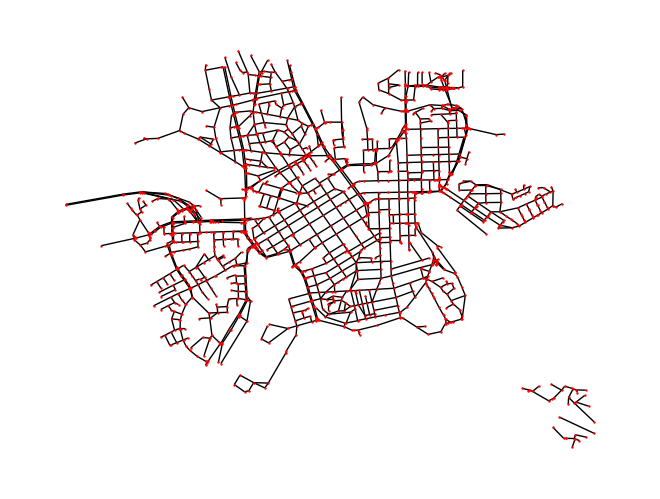

In [531]:
G = gdf_to_graph(streets)

positions = {node: (attrs["x"], attrs["y"]) for node, attrs in G.nodes.data()}

nx.draw(G, 
        pos=positions, 
        node_color="red",
        node_size=0.5,
       )

### Directed graph using a GeoDataFrame

Now as we have learned how to create a simple undirected graph based on `LineString` geometries, we will continue and expand the previous example to construct a directed graph topology that considers the permitted direction of movement along the streets. When working with street network data and analyzing e.g. the travel times or distances by car, it is necessary to take into consideration one-way streets as those are extremely common especially in larger cities. On these streets, a person can only drive to a specific direction, and if you would need to travel to opposite direction, making an U-turn would not be possible but you would need to travel further to find another path where the driving is permitted to the direction you are heading. Thus, one-way streets can have significant influence on the paths between given locations which need to be taken into account when doing network analysis. If directionality would not be taken into account (like in our previous example), our analyses and results will likely provide incorrect path suggestions and unrealistic results. 

In the following, we will continue working with the same street network as in our previous example but now we will create a directed graph where the permitted direction of travel is taken into consideration. Let's start again by reading the data:

In [547]:
import geopandas as gpd

fp = "data/digiroad_helsinki.gpkg"
streets = gpd.read_file(fp)
streets.head()

,id,direction,maxspeed,road_class,name,geometry
0,0,4,30,4,Uudenmaankatu,"LINESTRING Z (385359.222 6671266.76 8.729, 385..."
1,1,3,40,4,Pitkäsilta,"LINESTRING Z (386282.417 6672754.728 4.562, 38..."
2,2,3,30,5,Kruunuvuorenkatu,"LINESTRING Z (387294.871 6671561.901 2.24, 387..."
3,3,2,30,5,Kristianinkatu,"LINESTRING Z (386646.115 6672721.35 16.528, 38..."
4,4,2,30,5,Fabianinkatu,"LINESTRING Z (386225.349 6671530.049 8.246, 38..."


Here, the `direction` column includes information about the allowed direction of the traffic flow, i.e. whether the traffic is permitted in both directions or whether it is a oneway street. In this street network dataset the values are coded as shown in Table 8.1. As we can see based on these first five rows, there seem to be a couple of street segments that can be travelled to both directions indicated with value `2` (i.e. the edge should be bidirectional). In addition, there are couple of segments where the travel is permitted against the digitization direction (value `3`) and one where the travel is permitted in the direction of digitization. The direction of digitization basically means the order how the vertices (points) of a given `LineString` have been digitized when the data was created. 

: _**Table 8.1**. The rules for directed graph in terms of permitted direction of traffic._

| Value | Direction of traffic flow                                                             |
|-------|---------------------------------------------------------------------------------------|
| 2     | Traffic is permitted in both directions                                               |
| 3     | Traffic is permitted against the direction of digitization (end-node to start-node) |
| 4     | Traffic is permitted in the direction of digitization (start-node to end-node)      |




In [436]:
def gdf_to_directed_graph(gdf, direction='direction', both_ways=2, against=3, along=4):
    """Creates a NetworkX MultiDiGraph from road network GeoDataFrame.

    Parameters
    ----------

    gdf : GeoDataFrame
        GeoDataFrame containing the road network data.

    direction : str
        Name for column that contains information about the allowed driving directions

    both_ways : int
        Value specifying that the road is drivable to both directions.

    against : int
        Value specifying that the road is drivable against the digitizing direction.

    along : int
        Value specifying that the road is drivable along the digitizing direction.

    """

    # Create the NetworkX graph
    graph = nx.MultiDiGraph()
        
    # Generate edge dictionary
    for edge in gdf.itertuples():
        coords = edge.geometry.coords

        # Get first and last node of the edge (excluding vertices and possible Z coordinate)
        first, last = coords[0][:2], coords[-1][:2]

        # Edge attributes
        edge_attr = dict(edge._asdict())

        # Create edges according the direction rules
        if edge_attr[direction] == both_ways:

            # If road is bi-directional add it in both ways
            graph.add_edge(first, last, **edge_attr)
            graph.add_edge(last, first, **edge_attr)

        elif edge_attr[direction] == along:

            # Add the edge along digitization direction
            graph.add_edge(first, last, **edge_attr)

        elif edge_attr[direction] == against:
            
            # Add the edge against digitization direction
            graph.add_edge(last, first, **edge_attr)

    # Generate node attributes
    node_attrs = {node: {"coords": node, "x": node[0], "y": node[1]} for node in graph.nodes}
    nx.set_node_attributes(graph, node_attrs)  
    
    # Relabel the indices
    graph = nx.convert_node_labels_to_integers(graph)

    # Add some useful attributes    
    graph.graph['crs'] = gdf.crs

    return graph

In [439]:
G = gdf_to_directed_graph(streets)

In [440]:
positions = {node: attrs["coords"] for node, attrs in G.nodes.data()}

In [441]:
edge_colors = ["blue" if attrs["direction"] == 2 else "red" for u, v, attrs in G.edges.data()]

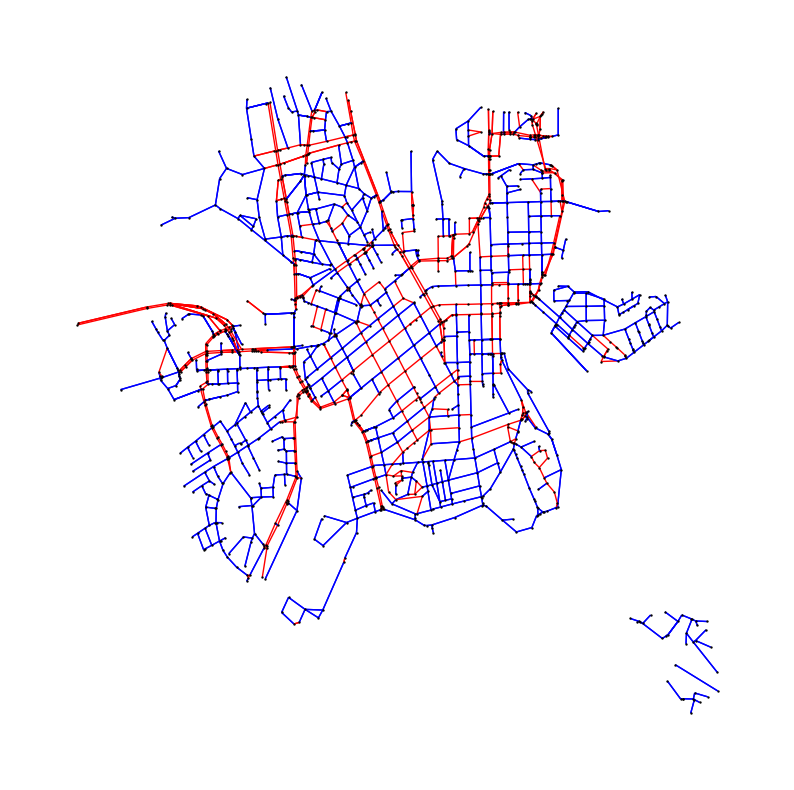

In [442]:
fig, ax = plt.subplots(figsize=(10,10))

nx.draw(G, 
        ax=ax,
        pos=positions, 
        node_color="black",
        node_size=0.5,
        edge_color=edge_colors,
        arrows=False,
       )

## Preparations for routing: Adding edge attributes

Next we will show how you can modify the network so that it is more useful for routing purposes. We will calculate the travel time it takes to cross a given street segment assuming that the person would be driving according the speed limits. The `maxspeed` column in our data provides information about the speed limit (km per hour) on a given street element. This is very useful information as we can use this to calculate the "free-flow" travel time which indicates the time it takes to cross a specific street segment assuming that a given person would be able to travel as fast as the speed limit allows. Notice that in cities, it is common that the actual driving speed can be lower than the speed limit due to congestion but we will ignore this for now to keep things simple. 

In [557]:
streets.head(2)

,id,direction,maxspeed,road_class,name,geometry,length_m,time_s
0,0,4,30,4,Uudenmaankatu,"LINESTRING Z (385359.222 6671266.76 8.729, 385...",87.053874,10
1,1,3,40,4,Pitkäsilta,"LINESTRING Z (386282.417 6672754.728 4.562, 38...",26.094526,2


Let's start by creating an attribute for travel time which we can calculate based on the length of the `LineString` and the `maxspeed` column. As we do not yet have information about the length stored in our data, we will also calculate and store it in a dedicated column called `length_m` (in meters). Notice that when calculating length, it is important that your input data is in projected coordinate system. In case your data has e.g. `WGS84` as the CRS, you should first reproject your data into an appropriate metric system (see Chapter 6.4). In our case, the input data is already in projected EUREF-FIN coordinate reference system having meters as units:

In [548]:
streets.crs.axis_info

[Axis(name=Easting, abbrev=E, direction=east, unit_auth_code=EPSG, unit_code=9001, unit_name=metre),
 Axis(name=Northing, abbrev=N, direction=north, unit_auth_code=EPSG, unit_code=9001, unit_name=metre)]

To calculate the length of each street segments, we can use the `.length` which returns the length of the lines in meters:

In [549]:
streets["length_m"] = streets.length
streets.head(2)

,id,direction,maxspeed,road_class,name,geometry,length_m
0,0,4,30,4,Uudenmaankatu,"LINESTRING Z (385359.222 6671266.76 8.729, 385...",87.053874
1,1,3,40,4,Pitkäsilta,"LINESTRING Z (386282.417 6672754.728 4.562, 38...",26.094526


Now we have all the information needed to calculate the free-flow travel time. To calculate the travel time in seconds, we can use a following formula that considers the speed limit information in km/h and the distance as meters (which is how our data is constructed in our `streets` dataset):

$$
t = \frac{3.6 \, d}{v}
$$

Where:  

- \(t\) = travel time in **seconds (s)**  
- \(d\) = distance in **meters (m)**  
- \(v\) = speed limit in **kilometers per hour (km/h)**

The multiplication of distance by 3.6 is a conversion factor between meters per second and kilometers per hour:

$$
1 \ \text{m/s} = \frac{3600}{1000} \ \text{km/h} = 3.6 \ \text{km/h}
$$

Let's now use the formula to calculate the travel time which we store in `time_s` column, rounding the value to a full second:

In [556]:
streets["time_s"] = 3.6 * streets["length_m"] / streets["maxspeed"]
streets["time_s"] = streets["time_s"].round(0).astype(int)
streets.head()

,id,direction,maxspeed,road_class,name,geometry,length_m,time_s
0,0,4,30,4,Uudenmaankatu,"LINESTRING Z (385359.222 6671266.76 8.729, 385...",87.053874,10
1,1,3,40,4,Pitkäsilta,"LINESTRING Z (386282.417 6672754.728 4.562, 38...",26.094526,2
2,2,3,30,5,Kruunuvuorenkatu,"LINESTRING Z (387294.871 6671561.901 2.24, 387...",162.028376,19
3,3,2,30,5,Kristianinkatu,"LINESTRING Z (386646.115 6672721.35 16.528, 38...",92.057341,11
4,4,2,30,5,Fabianinkatu,"LINESTRING Z (386225.349 6671530.049 8.246, 38...",96.171915,12


In [364]:
import osmnx as ox

In [431]:
nodes, edges = ox.graph_to_gdfs(G)

In [434]:
nodes.head()

,coords,x,y,geometry
osmid,,,,
0,"(385359.22199999995, 6671266.759999999)",385359.222,6671266.760,POINT (385359.222 6671266.76)
1,"(385429.82200000004, 6671317.645999999)",385429.822,6671317.646,POINT (385429.822 6671317.646)
2,"(386282.90299999993, 6672780.818)",386282.903,6672780.818,POINT (386282.903 6672780.818)
3,"(386282.4170000001, 6672754.728)",386282.417,6672754.728,POINT (386282.417 6672754.728)
4,"(387162.2939999999, 6671654.982999998)",387162.294,6671654.983,POINT (387162.294 6671654.983)


In [435]:
edges.head()

Index    id  direction  maxspeed  road_class              name  \
u v    key                                                                   
0 1    0        0     0          4        30           4     Uudenmaankatu   
1 140  0     1195  1201          4        30           4     Uudenmaankatu   
  1319 0     2335  2356          3        30           5      Albertinkatu   
2 3    0        1     1          3        40           4        Pitkäsilta   
3 1169 0     1196  1202          2        40           5  Kaisaniemenranta   

                                                     geometry  
u v    key                                                     
0 1    0    LINESTRING Z (385359.222 6671266.76 8.729, 385...  
1 140  0    LINESTRING Z (385429.822 6671317.646 8.732, 38...  
  1319 0    LINESTRING Z (385502.397 6671206.823 12.351, 3...  
2 3    0    LINESTRING Z (386282.417 6672754.728 4.562, 38...  
3 1169 0    LINESTRING Z (386282.417 6672754.728 4.562, 38...

As many Python libraries related to working with have been 

In [342]:
import neatnet

streets_cleaned = neatnet.remove_interstitial_nodes(streets)
streets_cleaned.shape

(2179, 7)